In [1]:
import argparse
from pathlib import Path

import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from scipy import optimize

from skimage import io as skio
from skimage.color import rgb2gray, rgb2hed
from skimage.filters import gaussian, median, sobel, frangi, threshold_otsu
from skimage.feature import structure_tensor
from skimage.measure import label, regionprops_table
from skimage.morphology import disk, remove_small_objects
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.transform import resize
from sklearn.decomposition import NMF
from sklearn.neighbors import NearestNeighbors
from pyimzml.ImzMLParser import ImzMLParser, getionimage

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
from pathlib import Path
from scipy.interpolate import RBFInterpolator
from scipy.optimize import minimize
from skimage import transform, filters
try:
    import SimpleITK as sitk
    SITK_AVAILABLE = True
except ImportError:
    SITK_AVAILABLE = False
    print("WARNING: SimpleITK not installed. B-spline registration unavailable.")
    print("Install with: pip install SimpleITK")
from pyimzml.ImzMLParser import ImzMLParser
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


In [2]:
FULL_HE_PATH = '/home/kia/MALDI_Metabolomics/metabol_data/high_res_MSI/D2_10x_originalExport.tif'
IMZML_PATH = '/home/kia/MALDI_Metabolomics/metabol_data/20251012_old_liver.imzML'
MALDI_IMG = '/home/kia/MALDI_Metabolomics/metabol_data/maldi_moving_img.png'

save the image in the exact dimensions given 

checking to see if the initial alignment gives us a reasonable coordinate structure 

# Fine Scale Alignment

Got the initial transform done with the correct cropped region 

In [3]:

def dbscan_1d_ish(imzml_path: str, mz_tol: float, min_intensity: float, min_count: int) -> pd.DataFrame:
    """
    Perform DBSCAN-like clustering on the m/z values in the dataframe. Clusters for now
    will be defined as contiguous regions where the difference between adjacent m/z values is less than mz_tol.
    Clusters with fewer than min_count points will be flagged as "noise".

    :param mz_tol: the tolerance for the m/z values
    :param min_intensity: the minimum intensity for a m/z to be considered
    :param min_count: the minimum number of points to form a cluster

    :return: a DataFrame with additional columns for delta_mz, in_dense_region, and cluster_labels
    :rtype: pandas.DataFrame
    """
    parser = ImzMLParser(imzml_path)
    df =pd.DataFrame(
                (   # neat trick to unpack the mzs and intensities directly into the row
                    # * is a unpacking operator called splat and it unpacks the tuple of mzs and intensities
                    # from getspectrum into individual elements in the new tuple
                    (*parser.getspectrum(idx), (x,y)) for idx, (x,y,_) in enumerate(parser.coordinates)
                ),
                    columns=["mzs", "intensities", "coordinates"]
        )
    # pull raw arrays out of the dataframe — no copies yet
    mzs_arr    = df['mzs'].to_numpy()
    intens_arr = df['intensities'].to_numpy()
    coords_arr = df['coordinates'].to_numpy()

    # single-pass concatenation — much faster than explode
    all_mzs    = np.concatenate(mzs_arr).astype(np.float32)
    all_intens = np.concatenate(intens_arr).astype(np.float32)
    lengths    = np.fromiter((len(a) for a in mzs_arr), dtype=np.int32, count=len(mzs_arr))
    all_coords = np.repeat(coords_arr, lengths)

    # filter BEFORE building the dataframe — avoids allocating rows you'll discard
    mask       = all_intens > min_intensity
    all_mzs    = all_mzs[mask]
    all_intens = all_intens[mask]
    all_coords = all_coords[mask]

    # sort on numpy arrays — faster than df.sort_values + reset_index
    print(f"Sorting m/z values...{mask.sum()} values")
    order      = np.argsort(all_mzs, kind='stable')

    print(f"building long_df")
    long_df = pd.DataFrame({
        'mzs':         all_mzs[order],
        'intensities': all_intens[order],
        'coordinates': all_coords[order],
    })

    
    print(f'\nlong_df columns: {long_df.columns}\n')  # print the columns of long_df.columns)
    
    # check if long
    # find the deltas between adjacent m/z values
    print("calculating deltas")
    delta_values = -1 * long_df['mzs'].values[0:(len(long_df) - min_count)] + long_df['mzs'].values[min_count:(len(long_df) + min_count)]
    
    # 0 padding missing values to match the length of the dataframe
    long_df['delta_mz'] = np.concatenate([delta_values, [0] * min_count])
    del delta_values

    # creating a boolean mask for regions where delta_mz < mz_tol
    long_df['in_dense_region'] = (long_df['delta_mz'] < mz_tol).astype(int)

    # Calculating difference of boolean flags
    # Calculate diff without fillna to get proper length n-1
    difference = np.diff(long_df['in_dense_region'].values)
    difference_plus = np.maximum(difference, 0)
    running_clusternr = np.cumsum(difference_plus)
    del difference
    del difference_plus

    # intermediate vector of of boolean flags
    delta = long_df['in_dense_region'].values

    # Now both have compatible shapes: delta[:-1] and running_clusternr are both length n-1
    clusternr = delta[:-1] * running_clusternr
    del running_clusternr

    # 0 padding missing values to match the length of the dataframe
    long_df['cluster_labels'] = np.concatenate([[delta[0]], clusternr])
    del clusternr
    del delta

    # Remove noise clusters
    # going to prune the data
    long_df = long_df[long_df["cluster_labels"] != 0]

    # Remove clusters with fewer than N mz values
    long_df = long_df[long_df.groupby('cluster_labels') ['mzs'].transform('size') >= min_count]

    import scipy.sparse as sp

    # grouping mzs based on the median of the cluster labels, and summing the intensities for each coordinate and mz_label pair
    print("Grouping m/z values and summing intensities...")
    grouped = (
        long_df
        .assign(mz_label=long_df.groupby('cluster_labels')['mzs'].transform('median'))
        .groupby(['coordinates', 'mz_label'])['intensities']
        .sum()
    )

    # Build integer codes for rows (coordinates) and cols (mz_label)
    print("Getting the coordinate and mz labels")
    coord_idx, coord_labels = pd.factorize(grouped.index.get_level_values('coordinates'))
    mz_idx,    mz_labels    = pd.factorize(grouped.index.get_level_values('mz_label'))
    
    # making it sparse to save memory
    print("Generating spot x feature matrix (sparse)...")
    spot_feature_matrix = sp.csr_matrix(
        (grouped.values, (coord_idx, mz_idx)),
        shape=(len(coord_labels), len(mz_labels))
    )


    return spot_feature_matrix, coord_labels, mz_labels


In [4]:
imzml_path = "/home/kia/MALDI_Metabolomics/metabol_data/20251012_old_liver.imzML"
spot_feature_matrix, coord_labels, mz_labels = dbscan_1d_ish(imzml_path, mz_tol=0.0042, min_intensity=5, min_count=25)

Sorting m/z values...39694844 values
building long_df

long_df columns: Index(['mzs', 'intensities', 'coordinates'], dtype='object')

calculating deltas
Grouping m/z values and summing intensities...
Getting the coordinate and mz labels
Generating spot x feature matrix (sparse)...


In [5]:
from skimage import color, morphology
from skimage.segmentation import clear_border

def compute_sinusoid_mask_from_he(he_img,
                                  max_size=10000,
                                  min_size=100,
                                  otsu_bias=1.0):
    # grayscale brightness
    gray = color.rgb2gray(he_img)               # (H, W), range [0, 1]

    # min(R,G,B) — high only when all channels are high (truly white)
    rgb_min = he_img.min(axis=-1)               # (H, W), range [0, 1]

    # combine: a pixel must be bright in both — filters pink (bright gray, low blue)
    white_signal = np.minimum(gray, rgb_min)    # (H, W)

    thr = threshold_otsu(white_signal) * otsu_bias
    interior = clear_border(white_signal > thr)

    large_enough = morphology.remove_small_objects(interior, max_size=min_size - 1)
    too_large    = morphology.remove_small_objects(interior, max_size=max_size - 1)
    return (large_enough ^ too_large).astype(np.float32)



In [6]:
import skimage

# then we get our sinusoid mask from the H&E image called S_HE in the manuscript
cropped_img = skimage.io.imread('/home/kia/MALDI_Metabolomics/metabol_data/high_res_MSI/he_cropped.tif')
he_img = skimage.io.imread('/home/kia/MALDI_Metabolomics/metabol_data/high_res_MSI/D2_10x_originalExport.tif')

In [7]:
maldi_coord_map = pd.read_csv('/home/kia/MALDI_Metabolomics/metabol_data/space_ranger_segmented_outputs/cell_segmentations_out3_pixel_warp_affine_vs_tps.csv')

# Align by native MSI pixel identity (msi_x, msi_y) rather than assuming the
# CSV's row order matches spot_feature_matrix's row order. pandas.groupby
# (used to build coord_labels in dbscan_1d_ish) sorts its keys by default,
# so coord_labels is NOT in the CSV's original row order — using positional
# alignment here would silently pair every MSI feature row with the wrong
# H&E-space coordinate.
msi_to_he = dict(zip(
    zip(maldi_coord_map['msi_x'].astype(float), maldi_coord_map['msi_y'].astype(float)),
    zip(maldi_coord_map['he_x_tps'], maldi_coord_map['he_y_tps'])
))
T0_maldi_coords = np.array([msi_to_he[(float(x), float(y))] for x, y in coord_labels])

xs = T0_maldi_coords[:, 0]
ys = T0_maldi_coords[:, 1]

x_min, x_max = int(xs.min()), int(xs.max()) + 1
y_min, y_max = int(ys.min()), int(ys.max()) + 1

In [8]:
SAVED_MASK = 1
if SAVED_MASK == 1: 
    cleaned_sinusoid_mask = skimage.io.imread('/home/kia/MALDI_Metabolomics/sinusoid_mask.tif')
else: print('Create new mask')
# correct — Otsu sees only real tissue pixels
#S_HE = compute_sinusoid_mask_from_he(cropped_img)

# if you need it back in full H&E coordinates afterward:
#S_HE_full = np.zeros(he_img.shape[:2], dtype=np.float32)
#S_HE_full[y_min:y_max, x_min:x_max] = S_HE

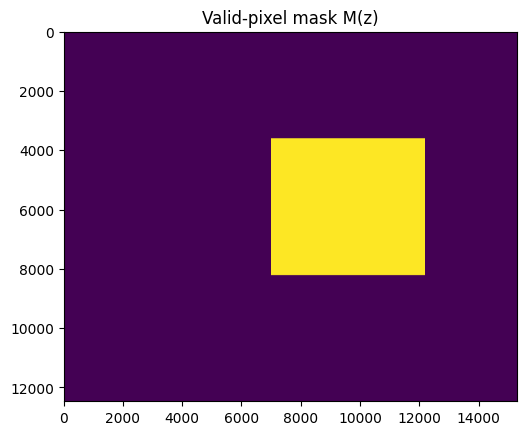

In [9]:
def build_valid_pixel_mask(full_shape, y_min, y_max, x_min, x_max):
    """
    Valid-pixel mask M(z) for the H&E image (paper Sec. 2.1).

    S_HE_full is zero everywhere outside the cropped tissue bounding box
    [y_min:y_max, x_min:x_max] — that's padding, not "no sinusoid here".
    M marks the region where S_HE_full actually carries information, so the
    Wendland convolution can be locally re-normalized instead of treating
    the padded border as real background.
    """
    M = np.zeros(full_shape[:2], dtype=np.float32)
    M[y_min:y_max, x_min:x_max] = 1.0
    return M

M = build_valid_pixel_mask(he_img.shape, y_min, y_max, x_min, x_max)

plt.imshow(M)
plt.title("Valid-pixel mask M(z)")
plt.show()

In [10]:
import numpy as np
from scipy.signal import convolve2d


def _create_wendland_kernel(h):
    """
    Create normalized Wendland C2 kernel.

    h = kernel support parameter
    """

    radius = int(np.ceil(np.sqrt(h)))

    x = np.arange(-radius, radius+1) # x length of kernel (2*radius+1)
    y = np.arange(-radius, radius+1) # y length (same as x)

    X, Y = np.meshgrid(x, y) # building the kernel grid 

    r2 = X**2 + Y**2 # radial area of influence

    kernel = np.zeros_like(r2, dtype=float) # making the kernel with the same shape as r2 but filled with zeros

    inside = r2 < h # boolean mask for the points that are within the cutoff radius h

    kernel[inside] = (
        (1 - r2[inside]/h)**4 *
        (4*r2[inside]/h + 1)
    ) # function for Wendland C2 kernel (determines influence of each pixel based on distance from center)

    # normalize C_h
    kernel /= kernel.sum()

    return kernel



def smooth_HE_mask(S_HE, h):
    """
    Wendland smoothing of binary H&E mask.

    S_HE:
        binary numpy array

    h:
        kernel support parameter
    """

    K_h = _create_wendland_kernel(h)

    S_HE_tilde = convolve2d(
        S_HE,
        K_h,
        mode="same",
        boundary="symm"
    )

    return S_HE_tilde

#S_HE_tilde = smooth_HE_mask(S_HE_full, h)
#plt.imshow(S_HE_tilde)
#plt.title("Smoothed sinusoid mask from H&E")
#plt.show()

In [11]:
from sklearn.neighbors import NearestNeighbors

# get the nearest neighbors of the T0_maldi_coords and the distance between these points
neigh = NearestNeighbors(n_neighbors=2)
neigh.fit(T0_maldi_coords)
distances, _ = neigh.kneighbors(T0_maldi_coords)
d_MSI = np.median(distances[:, 1])

# Wendland support radius, matching the paper's rho = (1+eta) * d_MSI / sqrt(2)
# (Sec 2.1). _create_wendland_kernel tests r2 < h, i.e. it treats its h
# argument as rho^2 (see Kp(x) using ||x||^2/rho^2), so h must be rho
# squared here — not rho itself.
eta = 0.1
rho = (1 + eta) * d_MSI / np.sqrt(2)
h = rho ** 2
r = d_MSI  # kept for any downstream reference to the old name

In [12]:
def smooth_mask_normalized(S_HE, M, h):
    """
    Locally-normalized Wendland smoothing (paper Sec. 2.1, eq. for f(z)).

    Plain convolution of S_HE alone treats padding outside the valid H&E
    domain as real "no sinusoid" background, dimming values near the crop
    edge. Instead we also convolve the valid-pixel mask M and divide it
    out, so each output pixel is renormalized by how much *valid* support
    the kernel actually had at that location.
    """
    K_h = _create_wendland_kernel(h)

    # numerator: raw smoothed sinusoid signal
    N = convolve2d(S_HE, K_h, mode="same", boundary="fill", fillvalue=0)

    # denominator: how much of the kernel's support fell inside valid H&E data
    D = convolve2d(M, K_h, mode="same", boundary="fill", fillvalue=0)

    # only defined where the kernel had at least some valid support
    f = np.zeros_like(N, dtype=np.float32)
    valid = D > 0
    f[valid] = N[valid] / D[valid]
    return f

S_smooth = smooth_mask_normalized(cleaned_sinusoid_mask, M, h)

#plt.imshow(S_smooth)
#plt.title("Boundary-corrected smoothed sinusoid mask f(z)")
#plt.show()

In [13]:
from scipy.ndimage import map_coordinates
def project_to_msi(S_smooth, T_U):
    """
    S_smooth: smoothed H&E image
    T_U: (N,2) transformed MSI coordinates in H&E space
    """

    # scipy uses (row, col) = (y, x)
    coords = np.vstack([T_U[:,1], T_U[:,0]])

    values = map_coordinates(
        S_smooth,
        coords,
        order=1,      # bilinear interpolation
        mode='nearest'
    )

    return values


s_T0 shape: (269511,)
s_T0 range: 0.0 to 1.0


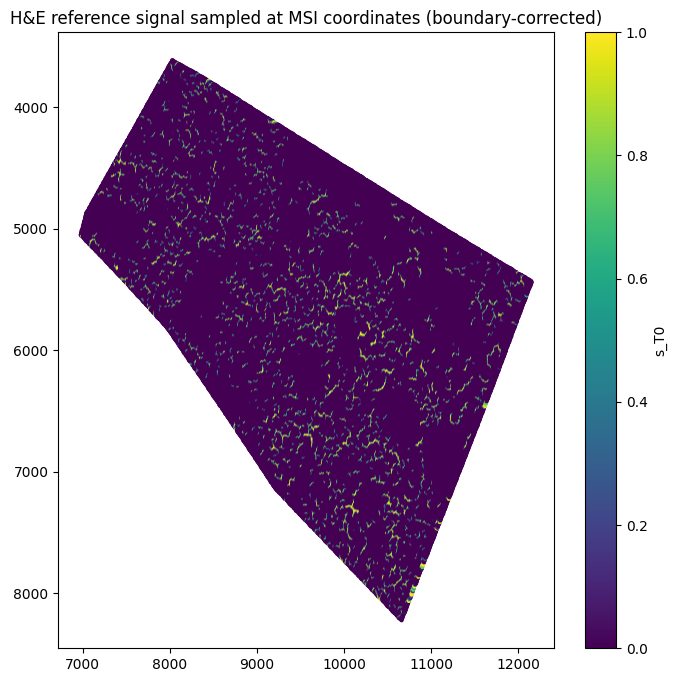

In [14]:
# s_T0(i) = f(T0(u_i)) — sample the boundary-corrected smooth field at each
# MSI pixel's H&E-space coordinate (paper Sec. 1, s_T definition). One row
# per MALDI spot, same order as spot_feature_matrix.
s_T0 = project_to_msi(S_smooth, T0_maldi_coords)

print("s_T0 shape:", s_T0.shape)
print("s_T0 range:", s_T0.min(), "to", s_T0.max())

plt.figure(figsize=(8, 8))
plt.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], c=s_T0, s=4, cmap="viridis")
plt.gca().invert_yaxis()
plt.colorbar(label="s_T0")
plt.title("H&E reference signal sampled at MSI coordinates (boundary-corrected)")
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler

def preprocess_features(spot_feature_matrix, low_pct=1, high_pct=99):
    """
    MSI feature preprocessing before ridge fitting (paper Sec. 2.2 requires
    centered/unit-variance features; log transform, TIC normalization, and
    outlier clipping are standard MSI preprocessing added on top of that).
    """
    X = spot_feature_matrix.toarray().astype(np.float32)

    # TIC (total ion current) normalization: divide each spot's intensities
    # by their sum, correcting for per-spot differences in overall
    # ionization efficiency before comparing intensities across spots.
    #tic = X.sum(axis=1, keepdims=True)
    #tic[tic == 0] = 1.0  # guard against empty spots
    #X = X / tic

    # log transform: raw MS intensities are heavy-tailed/skewed, which can
    # let a few extreme spots dominate both the percentile clip below and
    # the ridge fit itself. log1p handles the many exact-zero entries
    # (no signal for that m/z at that spot) without producing -inf.
    X = np.log1p(X)

    # clip each feature at its 1st/99th percentile so a handful of extreme
    # spots don't dominate the per-column mean/std computed next.
    lo = np.percentile(X, low_pct, axis=0)
    hi = np.percentile(X, high_pct, axis=0)
    X = np.clip(X, lo, hi)

    # center and scale each feature to unit variance
    X_scaled = StandardScaler().fit_transform(X)
    return X_scaled

X_scaled = preprocess_features(spot_feature_matrix)

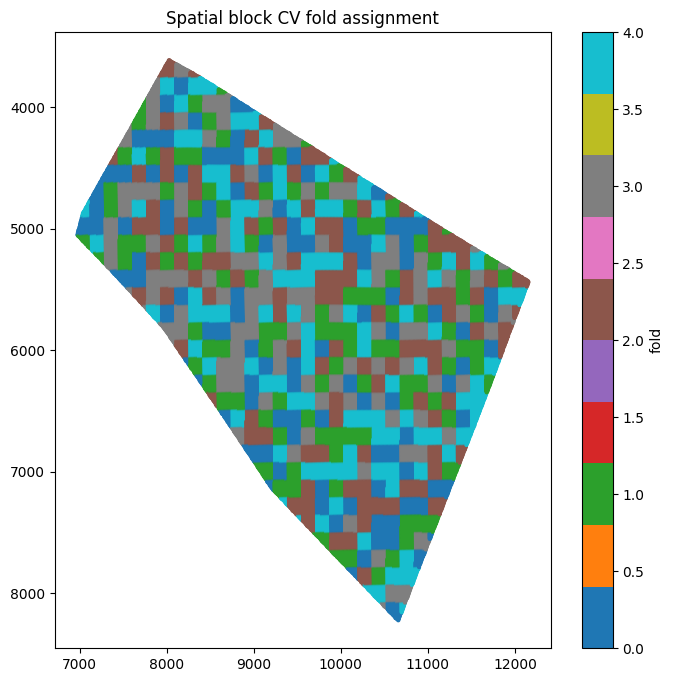

In [16]:
def spatial_block_cv(coords, n_blocks_per_axis=32, n_folds=5, min_block_size=20, random_state=0):
    """
    Spatial block CV fold assignment (paper Sec. 2.2). Random per-pixel folds
    would leak spatial autocorrelation between train/val; blocking on
    contiguous regions of the tissue avoids that.
    """
    x, y = coords[:, 0], coords[:, 1]
    x_edges = np.linspace(x.min(), x.max() + 1e-6, n_blocks_per_axis + 1)
    y_edges = np.linspace(y.min(), y.max() + 1e-6, n_blocks_per_axis + 1)
    bx = np.digitize(x, x_edges[1:-1])
    by = np.digitize(y, y_edges[1:-1])
    block_id = bx * n_blocks_per_axis + by

    # merge undersized boundary blocks into a grid-adjacent block that
    # already has enough points (paper Sec. 2.2: "merged with neighbouring blocks").
    unique_blocks, counts = np.unique(block_id, return_counts=True)
    for small_id in unique_blocks[counts < min_block_size]:
        bxi, byi = divmod(small_id, n_blocks_per_axis)
        neighbors = [(bxi + dx, byi + dy) for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]
                     if 0 <= bxi + dx < n_blocks_per_axis and 0 <= byi + dy < n_blocks_per_axis]
        for nbx, nby in neighbors:
            nb_id = nbx * n_blocks_per_axis + nby
            if nb_id != small_id and (block_id == nb_id).sum() >= min_block_size:
                block_id[block_id == small_id] = nb_id
                break

    # greedily assign blocks (in random order) to whichever fold currently has fewest pixels
    unique_blocks, counts = np.unique(block_id, return_counts=True)
    order = np.random.RandomState(random_state).permutation(len(unique_blocks))
    fold_loads = np.zeros(n_folds)
    block_to_fold = {}
    for idx in order:
        f = np.argmin(fold_loads)
        block_to_fold[unique_blocks[idx]] = f
        fold_loads[f] += counts[idx]

    fold_assignment = np.array([block_to_fold[b] for b in block_id])
    return block_id, fold_assignment

block_id, fold_assignment = spatial_block_cv(T0_maldi_coords)

# resulting 5-fold assignment
plt.figure(figsize=(8, 8))
plt.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], c=fold_assignment, s=4, cmap="tab10")
plt.gca().invert_yaxis()
plt.colorbar(label="fold")
plt.title("Spatial block CV fold assignment")
plt.show()

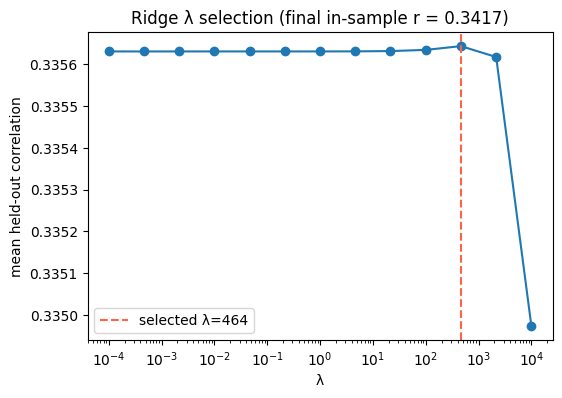

In [17]:
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr

def ridge_metafeature_fit(X, s, fold_assignment, lambdas):
    """
    Ridge metafeature learning with spatial block CV lambda selection
    (paper Sec. 2.2). For each candidate lambda, fit on 4 folds and score
    Pearson correlation on the held-out fold; pick the lambda that maximizes
    the average held-out correlation, then refit on all data.
    """
    n_folds = fold_assignment.max() + 1
    val_corr = np.zeros((len(lambdas), n_folds))
    for li, lam in enumerate(lambdas):
        for f in range(n_folds):
            train = fold_assignment != f
            val = ~train
            ridge = Ridge(alpha=lam, fit_intercept=False).fit(X[train], s[train])
            pred = X[val] @ ridge.coef_
            val_corr[li, f], _ = pearsonr(pred, s[val])

    mean_val_corr = val_corr.mean(axis=1)
    best_lambda = lambdas[np.argmax(mean_val_corr)]

    # refit on all data at the selected lambda, normalize to the canonical direction w_hat
    ridge_final = Ridge(alpha=best_lambda, fit_intercept=False).fit(X, s)
    w_hat = ridge_final.coef_ / np.linalg.norm(ridge_final.coef_)
    q = X @ w_hat
    return w_hat, q, best_lambda, mean_val_corr

# s_T is standardized to match X_scaled's unit-variance convention, so the
# lambda grid means the same thing on both sides of the ridge loss
s_scaled = StandardScaler().fit_transform(s_T0.reshape(-1, 1)).ravel()
lambdas = np.logspace(-4, 4, 13)
w_hat0, q0, best_lambda, mean_val_corr = ridge_metafeature_fit(X_scaled, s_scaled, fold_assignment, lambdas)
corr0, _ = pearsonr(q0, s_scaled)

plt.figure(figsize=(6, 4))
plt.semilogx(lambdas, mean_val_corr, marker="o")
plt.axvline(best_lambda, color="tomato", linestyle="--", label=f"selected λ={best_lambda:.3g}")
plt.xlabel("λ")
plt.ylabel("mean held-out correlation")
plt.title(f"Ridge λ selection (final in-sample r = {corr0:.4f})")
plt.legend()
plt.show()

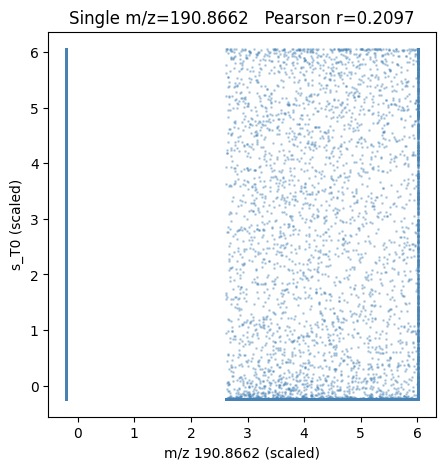

In [18]:
def test_single_mz(mz_value, mz_labels, X_scaled, s_scaled, fold_assignment, lambdas=None):
    """
    Sanity check: run the same ridge_metafeature_fit pipeline restricted to
    a single m/z channel, to see how much correlation one feature alone
    carries vs. the full metafeature combination.
    """
    if lambdas is None:
        lambdas = np.logspace(-3, 3, 13)

    idx = np.argmin(np.abs(mz_labels - mz_value))  # nearest matching m/z bin
    matched_mz = mz_labels[idx]

    X_single = X_scaled[:, [idx]]  # keep 2D shape (n, 1) for a single feature column
    w_hat, q, best_lambda, mean_val_corr = ridge_metafeature_fit(X_single, s_scaled, fold_assignment, lambdas)
    corr, _ = pearsonr(q, s_scaled)

    plt.figure(figsize=(5, 5))
    plt.scatter(q, s_scaled, s=1, alpha=0.3, c="steelblue")
    plt.xlabel(f"m/z {matched_mz:.4f} (scaled)")
    plt.ylabel("s_T0 (scaled)")
    plt.title(f"Single m/z={matched_mz:.4f}   Pearson r={corr:.4f}")
    plt.show()

    return matched_mz, corr, q

# example: try one specific m/z from your dataset
matched_mz, corr_sing, q_single = test_single_mz(190.8662, mz_labels, X_scaled, s_scaled, fold_assignment)

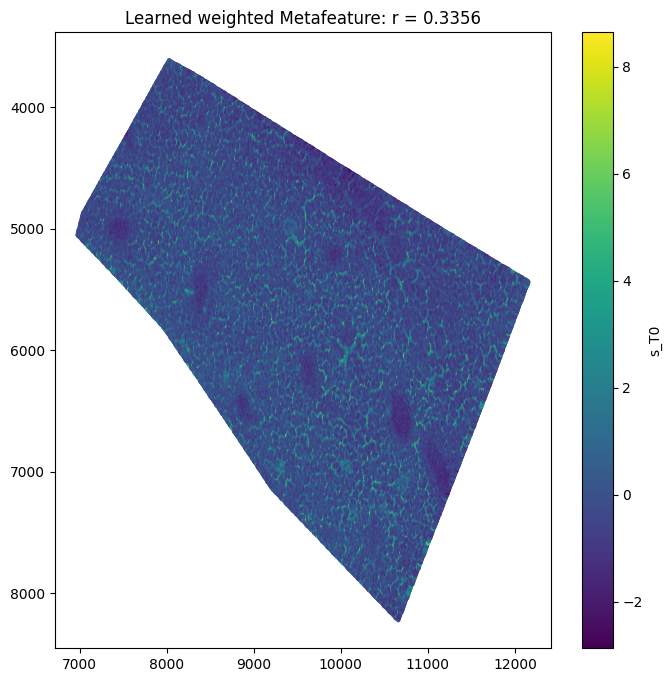

In [19]:
plt.figure(figsize=(8, 8))
plt.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], c=q0, s=4, cmap="viridis")
plt.gca().invert_yaxis()
plt.colorbar(label="s_T0")
plt.title(f"Learned weighted Metafeature: r = {np.mean(mean_val_corr):.4f}")
plt.savefig('Learned_Metafeature.png')
plt.show()

In [20]:
import napari

def view_signal_on_he_napari(he_img, coords_he, values):
    """
    Napari viewer: full H&E image with a points layer, one point per MSI
    pixel at its H&E-space coordinate, colored by a continuous value.
    """
    viewer = napari.Viewer()
    viewer.add_image(he_img, name="H&E", rgb=True)

    points_yx = coords_he[:, ::-1]  # napari 2D layers use (row, col) = (y, x)
    viewer.add_points(
        points_yx,
        name="s_T0",
        features={"value": values},
        face_color="value",
        face_colormap="viridis",
        size=15,
        border_width=0,
    )
    return viewer

#viewer_he = view_signal_on_he_napari(he_img, T0_maldi_coords, s_T0)

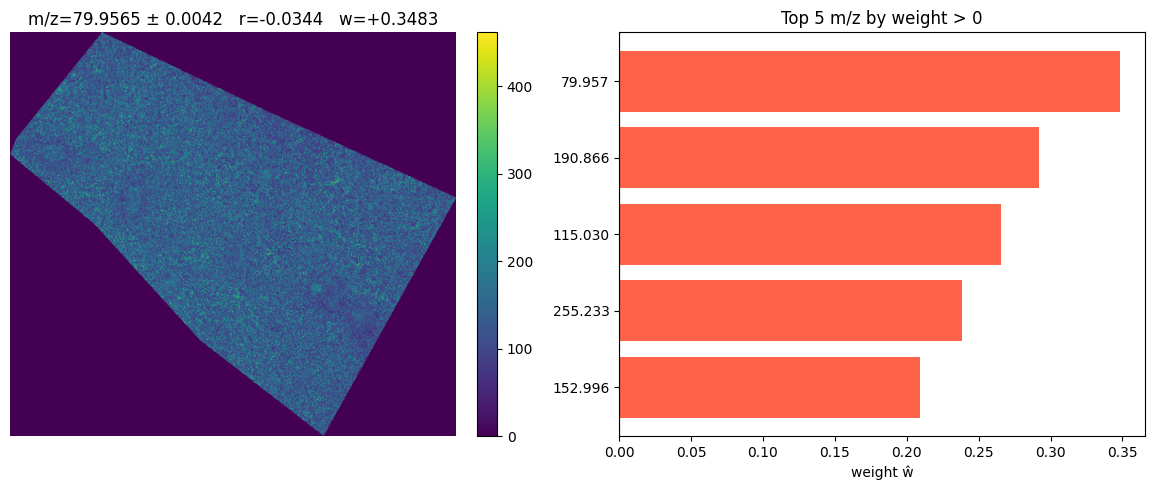

In [21]:
def plot_top_weighted_ion_maps(w_hat, mz_labels, X_scaled, s_scaled, parser, top_n=5, mz_tol=0.0042):
    """
    Diagnostic: ion map of the single top-weighted m/z feature, read
    straight from the raw imzML data via getionimage (left), next to a bar
    chart of the top-n |weight| contributors to the learned metafeature (right).
    """
    #top_idx = np.argsort(np.abs(w_hat))[::-1][:top_n]
    top_idx = np.argsort(w_hat)[::-1][:top_n]
    top_feature_idx = top_idx[0]
    top_mz = mz_labels[top_feature_idx]

    ion_img = getionimage(parser, top_mz, tol=mz_tol)
    r_top, _ = pearsonr(X_scaled[:, top_feature_idx], s_scaled)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    im = axes[0].imshow(ion_img, cmap="viridis")
    axes[0].set_title(f"m/z={top_mz:.4f} ± {mz_tol}   r={r_top:.4f}   w={w_hat[top_feature_idx]:+.4f}")
    axes[0].axis("off")
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    top_mz_str = [f"{mz_labels[i]:.3f}" for i in top_idx[::-1]]
    top_weights = w_hat[top_idx[::-1]]
    axes[1].barh(top_mz_str, top_weights, color=["tomato" if w > 0 else "steelblue" for w in top_weights])
    axes[1].axvline(0, color="k", lw=0.8)
    axes[1].set_xlabel("weight ŵ")
    #axes[1].set_title(f"Top {top_n} m/z by |weight|")
    axes[1].set_title(f"Top {top_n} m/z by weight > 0")
    plt.savefig('Loadings_of_Metafeature.png')
    plt.tight_layout()
    plt.show()
    return top_idx

maldi_parser = ImzMLParser('/home/kia/MALDI_Metabolomics/metabol_data/20251012_old_liver.imzML')
top_idx = plot_top_weighted_ion_maps(w_hat0, mz_labels, X_scaled, s_scaled, maldi_parser)

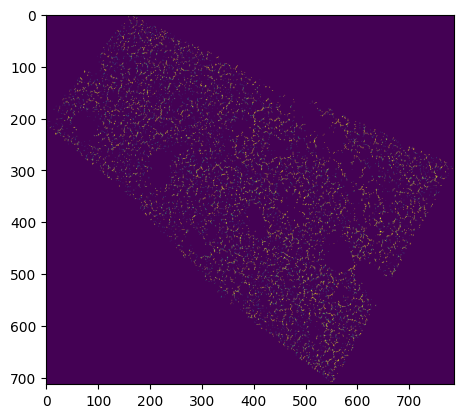

In [22]:
ion_mat = getionimage(maldi_parser, mz_value=190.8660, tol=.0042)
plt.imshow(ion_mat, vmin=np.percentile(ion_mat,1), vmax=np.percentile(ion_mat, 99))

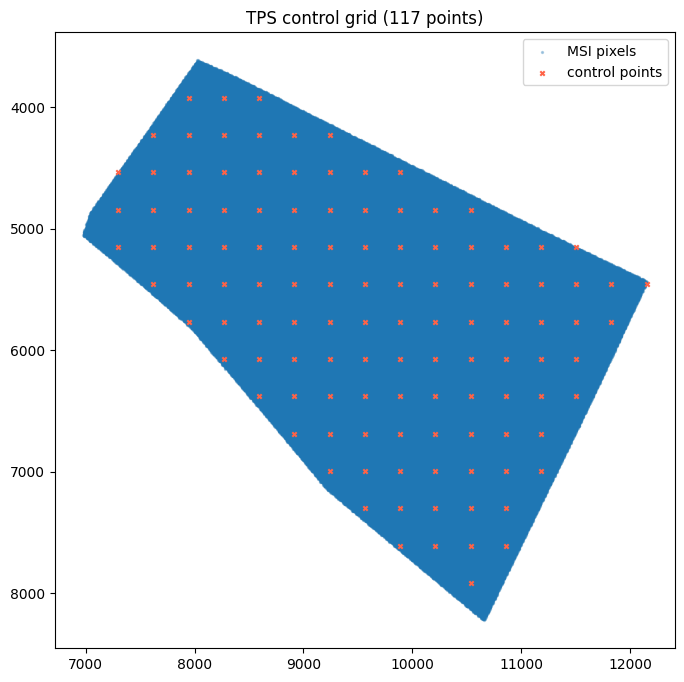

In [23]:
def build_control_grid(coords, d_msi, spacing_factor=50, max_dist_factor=1.0):
    """
    Sparse regular grid of TPS control points spanning the MSI footprint
    (paper Sec. 1: Delta^TPS is "parameterised by a sparse set of control
    points"), spaced spacing_factor * d_MSI apart. Grid points that land
    outside the actual tissue footprint (e.g. in the bounding-box corners,
    since the footprint is a rotated blob, not a rectangle) are dropped —
    they'd have no nearby data to inform their displacement anyway.

    The distance cutoff is scaled by d_msi (the data's own pixel spacing),
    not by the control-grid spacing itself — the latter would make the
    cutoff coarser as the grid gets sparser, letting control points sit
    well outside the tissue near irregular/concave boundary regions.
    """
    spacing = spacing_factor * d_msi
    x_min, x_max = coords[:, 0].min(), coords[:, 0].max()
    y_min, y_max = coords[:, 1].min(), coords[:, 1].max()

    n_x = max(2, int(np.ceil((x_max - x_min) / spacing)) + 1)
    n_y = max(2, int(np.ceil((y_max - y_min) / spacing)) + 1)
    cx = np.linspace(x_min, x_max, n_x)
    cy = np.linspace(y_min, y_max, n_y)
    CX, CY = np.meshgrid(cx, cy)
    grid_points = np.column_stack([CX.ravel(), CY.ravel()])

    # drop grid points too far from any actual MSI coordinate, relative to
    # the data's own spacing (not the sparser control-grid spacing)
    neigh = NearestNeighbors(n_neighbors=1).fit(coords)
    dist_to_data, _ = neigh.kneighbors(grid_points)
    control_points = grid_points[dist_to_data.ravel() < max_dist_factor * d_msi]
    return control_points

control_points = build_control_grid(T0_maldi_coords, d_MSI)

plt.figure(figsize=(8, 8))
plt.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], s=2, alpha=0.3, label="MSI pixels")
plt.scatter(control_points[:, 0], control_points[:, 1], s=10, c="tomato", marker="x", label="control points")
plt.gca().invert_yaxis()
plt.legend()
plt.title(f"TPS control grid ({len(control_points)} points)")
plt.show()

In [24]:
from scipy.spatial.distance import cdist

def tps_kernel(r):
    """Classical TPS radial basis function U(r) = r^2 log(r) (U(0) = 0)."""
    with np.errstate(divide="ignore", invalid="ignore"):
        out = np.where(r > 0, r**2 * np.log(r), 0.0)
    return out

def build_tps_basis(control_points, query_points):
    """
    TPS design matrices (paper Sec. 1/2.3: Delta^TPS parameterised by a
    sparse set of control points; classical TPS bending energy E_bend).
    K: (m,m) kernel between control points, used both to solve for the
       RBF coefficients and to compute the bending energy c^T K c.
    P: (m,3) affine design [1,x,y] at control points; the natural TPS
       boundary condition P^T c = 0 keeps affine motion out of the RBF
       part, so E_bend penalises only non-affine bending.
    Phi, Q: the same bases evaluated at the query points (all MSI
       pixels), used to evaluate the dense displacement field.
    """
    K = tps_kernel(cdist(control_points, control_points))
    P = np.column_stack([np.ones(len(control_points)), control_points])
    Phi = tps_kernel(cdist(query_points, control_points))
    Q = np.column_stack([np.ones(len(query_points)), query_points])
    return K, P, Phi, Q

def solve_tps_coeffs(K, P, targets):
    """
    Solve the standard TPS linear system for one displacement axis:
    [K P; P^T 0] [c; a] = [targets; 0]. Returns RBF coeffs c and affine
    coeffs a.
    """
    m = K.shape[0]
    A = np.block([[K, P], [P.T, np.zeros((3, 3))]])
    rhs = np.concatenate([targets, np.zeros(3)])
    sol = np.linalg.solve(A, rhs)
    return sol[:m], sol[m:]

def evaluate_tps_field(Phi, Q, c, a):
    """Dense displacement values at the query points, given RBF/affine coeffs."""
    return Phi @ c + Q @ a

def tps_bending_energy(K, c_x, c_y):
    """Classical TPS bending energy, summed over the x and y displacement components."""
    return c_x @ K @ c_x + c_y @ K @ c_y

K, P, Phi, Q = build_tps_basis(control_points, T0_maldi_coords)
print("K:", K.shape, " P:", P.shape, " Phi:", Phi.shape, " Q:", Q.shape)

K: (117, 117)  P: (117, 3)  Phi: (269511, 117)  Q: (269511, 3)


In [25]:
def tps_objective(params, K, P, Phi, Q, T0_coords, S_smooth, q, lambda_tps):
    """
    Negative TPS objective (paper Sec. 2.3):
    rho(q, s_T1) - lambda_TPS * E_bend(Delta_TPS), negated for minimize().
    params is the flattened [dx_ctrl; dy_ctrl] control-point displacement
    vector (length 2m); q is the frozen metafeature score from ridge
    fitting, held fixed throughout this optimization.
    """
    m = K.shape[0]
    dx_ctrl, dy_ctrl = params[:m], params[m:]

    # solve each displacement axis's TPS system, then evaluate the dense
    # field at every MSI pixel (reusing the same K/P/Phi/Q basis matrices,
    # which don't change — only the target displacement values do)
    c_x, a_x = solve_tps_coeffs(K, P, dx_ctrl)
    c_y, a_y = solve_tps_coeffs(K, P, dy_ctrl)
    dx = evaluate_tps_field(Phi, Q, c_x, a_x)
    dy = evaluate_tps_field(Phi, Q, c_y, a_y)

    T1_coords = T0_coords + np.column_stack([dx, dy])
    s_T1 = project_to_msi(S_smooth, T1_coords)
    corr, _ = pearsonr(q, s_T1)

    E_bend = tps_bending_energy(K, c_x, c_y)
    return -(corr - lambda_tps * E_bend)

In [26]:
def optimize_tps(K, P, Phi, Q, T0_coords, S_smooth, q, d_msi,
                  lambda_tps=3.0, displacement_cap_factor=10, maxiter=100,
                  n_subsample=None, random_state=0):
    """
    Fit TPS control-point displacements by maximizing rho(q, s_T1) -
    lambda_TPS * E_bend (paper Sec. 2.3), via L-BFGS-B. The box bounds
    implement the paper's "loose displacement bounds" -- a generous cap
    (here, a multiple of d_MSI) that should not bind in a well-behaved fit.

    L-BFGS-B's default finite-difference step (~1.49e-8, absolute) is far
    below float32 precision at our coordinate scale (d_MSI ~ 6.5), so the
    numerical gradient underflows to exactly zero and the optimizer
    "converges" at iteration 0 without moving. eps is set to ~1% of
    d_MSI instead -- large enough to register a real change in S_smooth's
    bilinearly-interpolated value, small enough to stay a good local
    derivative estimate.

    n_subsample: if given, evaluate the objective on a random subsample of
    this many MSI pixels instead of all n, for speed -- cost scales with
    n, so this is an independent speedup on top of a sparser control grid.
    Phi/Q/T0_coords/q are all subsampled together (same random rows), so
    each pixel's basis row, position, and target score stay matched up.
    The fitted result is still evaluated on all pixels afterward in
    apply_tps; this only affects what's used *during* optimization.
    """
    m = K.shape[0]
    x0 = np.zeros(2 * m)  # start from T0, i.e. zero residual displacement
    cap = displacement_cap_factor * d_msi
    bounds = [(-cap, cap)] * (2 * m)
    eps = 0.01 * d_msi

    if n_subsample is not None and n_subsample < len(T0_coords):
        rng = np.random.RandomState(random_state)
        sub_idx = rng.choice(len(T0_coords), size=n_subsample, replace=False)
        Phi_use, Q_use, T0_use, q_use = Phi[sub_idx], Q[sub_idx], T0_coords[sub_idx], q[sub_idx]
    else:
        Phi_use, Q_use, T0_use, q_use = Phi, Q, T0_coords, q

    result = minimize(
        tps_objective, x0,
        args=(K, P, Phi_use, Q_use, T0_use, S_smooth, q_use, lambda_tps),
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": maxiter, "disp": True, "eps": eps},
    )
    return result

# timing test first -- see how long a handful of iterations takes before
# committing to a full optimization run
import time
t0 = time.time()
result = optimize_tps(K, P, Phi, Q, T0_maldi_coords, S_smooth, q0, d_MSI, maxiter=100, n_subsample=65000)
print(f"elapsed for maxiter=3: {time.time() - t0:.1f}s   converged: {result.success}   nit: {result.nit}")

elapsed for maxiter=3: 248.3s   converged: False   nit: 47


stopped because: STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT
correlation before TPS (T0): 0.3417   after TPS (T1): 0.4814


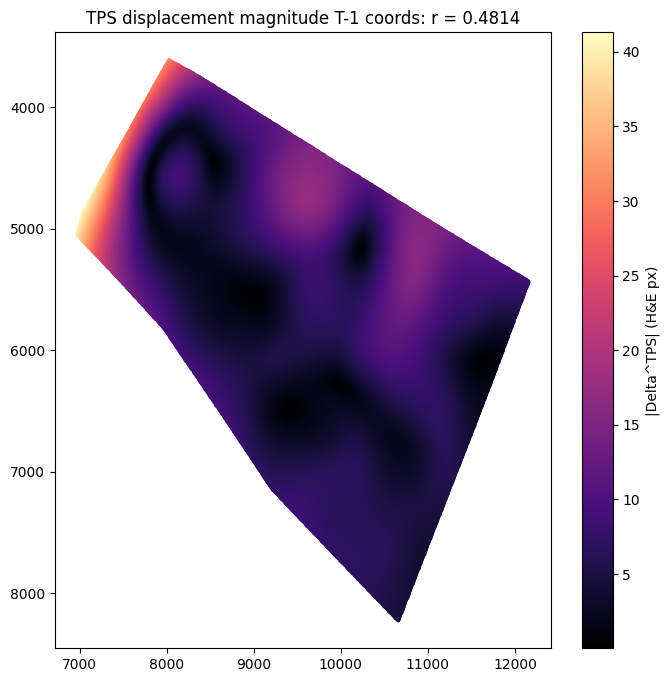

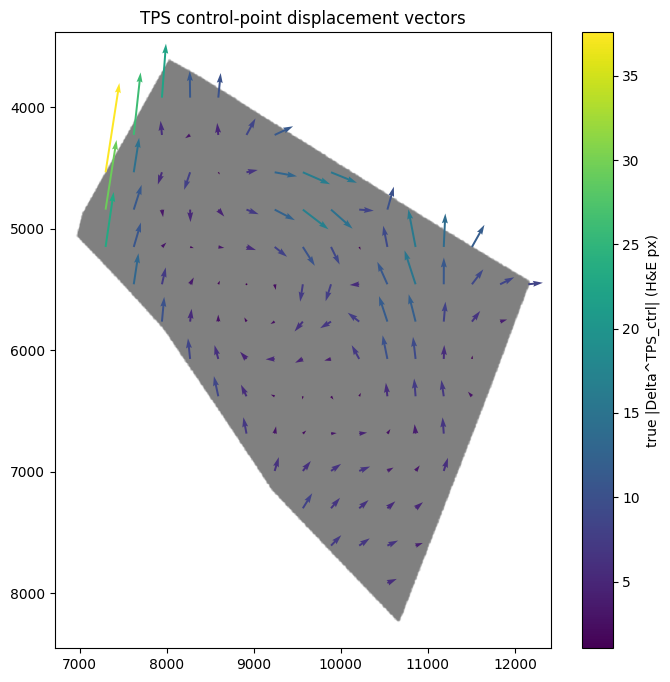

In [27]:
def apply_tps(result, K, P, Phi, Q, T0_coords):
    """
    Evaluate the fitted TPS control-point displacements over all MSI
    pixels (paper: T1(u_i) = T0(u_i) + Delta^TPS(u_i)). Uses result.x
    regardless of result.success -- it's the best solution found within
    the iteration budget, not garbage if maxiter was hit first.
    """
    m = K.shape[0]
    dx_ctrl, dy_ctrl = result.x[:m], result.x[m:]
    c_x, a_x = solve_tps_coeffs(K, P, dx_ctrl)
    c_y, a_y = solve_tps_coeffs(K, P, dy_ctrl)
    dx = evaluate_tps_field(Phi, Q, c_x, a_x)
    dy = evaluate_tps_field(Phi, Q, c_y, a_y)
    T1_coords = T0_coords + np.column_stack([dx, dy])
    return T1_coords, dx, dy, dx_ctrl, dy_ctrl

print("stopped because:", result.message)
T1_coords, dx_TPS, dy_TPS, dx_ctrl, dy_ctrl = apply_tps(result, K, P, Phi, Q, T0_maldi_coords)

corr_T1, _ = pearsonr(q0, project_to_msi(S_smooth, T1_coords))
print(f"correlation before TPS (T0): {corr0:.4f}   after TPS (T1): {corr_T1:.4f}")

# displacement magnitude over all MSI pixels
disp_mag = np.sqrt(dx_TPS**2 + dy_TPS**2)
plt.figure(figsize=(8, 8))
plt.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], c=disp_mag, s=4, cmap="magma")
plt.gca().invert_yaxis()
plt.colorbar(label="|Delta^TPS| (H&E px)")
plt.title(f"TPS displacement magnitude T-1 coords: r = {corr_T1:.4f}")
plt.show()

# control-point-level displacement vectors -- the actual optimized parameters.
# Arrows are drawn EXAGGERATED (scaled up by exaggeration) purely so they're
# visible against the tissue's thousands-of-units extent; color encodes the
# true (non-exaggerated) displacement magnitude.
ctrl_mag = np.sqrt(dx_ctrl**2 + dy_ctrl**2)
exaggeration = 20
plt.figure(figsize=(8, 8))
plt.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], s=2, alpha=0.15, c="gray")
q_plot = plt.quiver(
    control_points[:, 0], control_points[:, 1],
    dx_ctrl * exaggeration, dy_ctrl * exaggeration,
    ctrl_mag, cmap="viridis",
    angles="xy", scale_units="xy", scale=1,
    width=0.004,
)
plt.colorbar(q_plot, label="true |Delta^TPS_ctrl| (H&E px)")
plt.gca().invert_yaxis()
plt.title(f"TPS control-point displacement vectors")
plt.show()

In [28]:
# saving the T1_coords 
t1_coords_df = pd.DataFrame(T1_coords, columns=[['X', 'Y']])
t1_coords_df.to_csv('T1_finescale.csv')

In [29]:
import napari

def view_signals_on_he_napari(he_img, layers, point_size=6):
    """
    Napari viewer: full H&E image with one points layer per entry in
    `layers`, each colored by its own continuous value. Only non-zero
    points are plotted per layer.

    layers: list of dicts, each with keys:
        "name":      layer name (str)
        "coords_he": (N, 2) array of (x, y) H&E-space coordinates
        "values":    (N,) array of values, same length as coords_he
        "colormap":  (optional) napari colormap name, default "viridis"
    """
    viewer = napari.Viewer()
    viewer.add_image(he_img, name="H&E", rgb=True)

    for layer in layers:
        coords_he = layer["coords_he"]
        values = np.asarray(layer["values"])
        colormap = layer.get("colormap", "viridis")

        mask = values > 0
        sig_values = values[mask]
        points_yx = coords_he[:, ::-1]  # napari 2D layers use (row, col) = (y, x)
        sig_pts = points_yx[mask]

        viewer.add_points(
            sig_pts,
            name=layer["name"],
            features={"value": sig_values},
            face_color="value",
            face_colormap=colormap,
            size=point_size,
            border_width=0,
        )

    napari.run()
    return viewer

def get_mz_column(spot_feature_matrix, mz_labels, mz_value, mz_tol=0.0042):
    """Extract the intensity column for the m/z bin nearest mz_value."""
    idx = np.argmin(np.abs(mz_labels - mz_value))
    matched_mz = mz_labels[idx]
    if abs(matched_mz - mz_value) > mz_tol:
        print(f"Warning: nearest bin {matched_mz:.4f} is {abs(matched_mz-mz_value):.4f} away from requested {mz_value}")
    values = np.asarray(spot_feature_matrix[:, idx].todense()).ravel()
    return values, matched_mz

mz_value = 190.8660
mz_values, matched_mz = get_mz_column(spot_feature_matrix, mz_labels, mz_value)

viewer = view_signals_on_he_napari(
    he_img,
    layers=[
        {"name": "learned_metafeature", "coords_he": T1_coords, "values": q0, "colormap": "viridis"},
        {"name": "tps_displacement_magnitude", "coords_he": T0_maldi_coords, "values": disp_mag, "colormap": "magma"},
        {"name": f"mz_{matched_mz:.4f}", "coords_he": T0_maldi_coords, "values": mz_values, "colormap": "plasma"},
    ],
    point_size=6,
)

def tps_lambda_sweep(K, P, Phi, Q, T0_coords, S_smooth, q, d_msi, lambdas_tps,
                      n_subsample=65000, maxiter=100, random_state=0):
    """
    Compare TPS fits across a range of lambda_TPS values, to check whether
    the current lambda under-regularizes (patchy/overfit field) vs.
    producing a genuinely smooth broad correction. Uses the same random
    subsample for every lambda (fixed random_state) so the comparison
    isn't confounded by different random subsets, and evaluates the final
    correlation on the FULL dataset (not the subsample) for a fair
    apples-to-apples number across lambdas.
    """
    results = []
    for lam in lambdas_tps:
        res = optimize_tps(K, P, Phi, Q, T0_coords, S_smooth, q, d_msi,
                            lambda_tps=lam, maxiter=maxiter,
                            n_subsample=n_subsample, random_state=random_state)
        T1_lam, dx_lam, dy_lam, dx_ctrl_lam, dy_ctrl_lam = apply_tps(res, K, P, Phi, Q, T0_coords)
        corr_lam, _ = pearsonr(q, project_to_msi(S_smooth, T1_lam))
        results.append({"lambda": lam, "result": res, "dx": dx_lam, "dy": dy_lam, "corr": corr_lam})
        print(f"lambda={lam:.1e}   converged={res.success}   nit={res.nit}   corr(full)={corr_lam:.4f}")
    return results

lambdas_tps = [1, 3, 10, 100]
sweep_results = tps_lambda_sweep(K, P, Phi, Q, T0_maldi_coords, S_smooth, q0, d_MSI, lambdas_tps)

# displacement magnitude side by side, one panel per lambda
fig, axes = plt.subplots(1, len(sweep_results), figsize=(5 * len(sweep_results), 5))
for ax, res in zip(axes, sweep_results):
    disp_mag = np.sqrt(res["dx"]**2 + res["dy"]**2)
    sc = ax.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], c=disp_mag, s=2, cmap="magma")
    ax.invert_yaxis()
    ax.set_title(f"λ_TPS={res['lambda']:.0e}\ncorr={res['corr']:.4f}")
    fig.colorbar(sc, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

# correlation vs lambda, with T0's baseline for reference
plt.figure(figsize=(6, 4))
plt.semilogx([r["lambda"] for r in sweep_results], [r["corr"] for r in sweep_results], marker="o")
plt.axhline(corr0, color="gray", linestyle="--", label="corr0 (T0, no TPS)")
plt.xlabel("λ_TPS")
plt.ylabel("correlation (T1, full dataset)")
plt.legend()
plt.title("TPS correlation vs bending-energy weight")
plt.show()

for res in sweep_results:
    m = K.shape[0]
    dx_ctrl_r, dy_ctrl_r = res["result"].x[:m], res["result"].x[m:]
    c_x_r, _ = solve_tps_coeffs(K, P, dx_ctrl_r)
    c_y_r, _ = solve_tps_coeffs(K, P, dy_ctrl_r)
    e_bend = tps_bending_energy(K, c_x_r, c_y_r)
    print(f"lambda={res['lambda']:.1e}   E_bend={e_bend:.4e}   lambda*E_bend={res['lambda']*e_bend:.4e}")

In [30]:
import napari
from qtpy.QtWidgets import QWidget, QVBoxLayout, QHBoxLayout, QLabel, QSlider
from qtpy.QtCore import Qt

def _add_point_size_widget(viewer, points_layers, size_range=(1, 50)):
    """
    Dock widget with one slider per points layer, so each layer's point
    size can be adjusted independently. The built-in napari size slider
    only rescales points while they're selected / in add mode -- setting
    layer.size directly on the full array is what actually resizes
    already-plotted points.
    """
    panel = QWidget()
    layout = QVBoxLayout()
    panel.setLayout(layout)

    for pts_layer in points_layers:
        row = QHBoxLayout()
        label = QLabel(pts_layer.name)
        slider = QSlider(Qt.Horizontal)
        slider.setMinimum(size_range[0])
        slider.setMaximum(size_range[1])
        current = int(np.atleast_1d(pts_layer.size).ravel()[0]) if len(pts_layer.data) else size_range[0]
        slider.setValue(current)

        def make_callback(layer):
            def callback(value):
                layer.size = np.full(len(layer.data), value)
                layer.refresh()
            return callback

        slider.valueChanged.connect(make_callback(pts_layer))

        row.addWidget(label)
        row.addWidget(slider)
        layout.addLayout(row)

    viewer.window.add_dock_widget(panel, area="right", name="Point Sizes")
    return panel

def view_signals_on_he_napari(he_img, layers, point_size=6):
    """
    Napari viewer: full H&E image with one points layer per entry in
    `layers`, each colored by its own continuous value. Only non-zero
    points are plotted per layer. A "Point Sizes" dock widget on the
    right lets each layer's point size be adjusted independently.

    layers: list of dicts, each with keys:
        "name":      layer name (str)
        "coords_he": (N, 2) array of (x, y) H&E-space coordinates
        "values":    (N,) array of values, same length as coords_he
        "colormap":  (optional) napari colormap name, default "viridis"
    """
    viewer = napari.Viewer()
    viewer.add_image(he_img, name="H&E", rgb=True)

    points_layers = []
    for layer in layers:
        coords_he = layer["coords_he"]
        values = np.asarray(layer["values"])
        colormap = layer.get("colormap", "viridis")

        mask = values > 0
        sig_values = values[mask]
        points_yx = coords_he[:, ::-1]  # napari 2D layers use (row, col) = (y, x)
        sig_pts = points_yx[mask]

        pts_layer = viewer.add_points(
            sig_pts,
            name=layer["name"],
            features={"value": sig_values},
            face_color="value",
            face_colormap=colormap,
            size=point_size,
            border_width=0,
        )
        points_layers.append(pts_layer)

    _add_point_size_widget(viewer, points_layers)

    napari.run()
    return viewer

def get_mz_column(spot_feature_matrix, mz_labels, mz_value, mz_tol=0.0042):
    """Extract the intensity column for the m/z bin nearest mz_value."""
    idx = np.argmin(np.abs(mz_labels - mz_value))
    matched_mz = mz_labels[idx]
    if abs(matched_mz - mz_value) > mz_tol:
        print(f"Warning: nearest bin {matched_mz:.4f} is {abs(matched_mz-mz_value):.4f} away from requested {mz_value}")
    values = np.asarray(spot_feature_matrix[:, idx].todense()).ravel()
    return values, matched_mz

mz_value = 190.8660
mz_values, matched_mz = get_mz_column(spot_feature_matrix, mz_labels, mz_value)

viewer = view_signals_on_he_napari(
    he_img,
    layers=[
        {"name": "learned_metafeature", "coords_he": T0_maldi_coords, "values": q0, "colormap": "viridis"},
        {"name": "tps_displacement_magnitude", "coords_he": T0_maldi_coords, "values": disp_mag, "colormap": "magma"},
        {"name": f"mz_{matched_mz:.4f}", "coords_he": T1_coords, "values": mz_values, "colormap": "plasma"},
      ],
    point_size=6,
)